<a href="https://colab.research.google.com/github/TayBrig-Data/data101-final-project/blob/main/Data_Science_Project_Regression_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Loading both data sets into the model

In [1]:
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt

# Load the datasets
calendar_df = pd.read_csv('/content/Calender_data_cleaned.csv')
nvidia_df = pd.read_csv('/content/NVidia_stock_history_formatted.csv')

# Display the first few rows to understand the structure
display(calendar_df.head())
display(nvidia_df.head())

,id,date,zone,currency,importance,event,actual
0,399118,2020-01-02,united states,USD,medium,Continuing Jobless Claims,"1,728K"
1,399117,2020-01-02,united states,USD,high,Initial Jobless Claims,222K
2,399269,2020-01-03,united kingdom,GBP,medium,Nationwide HPI (MoM) (Dec),0.1%
3,399272,2020-01-03,united kingdom,GBP,medium,Nationwide HPI (YoY) (Dec),1.4%
4,398410,2020-01-03,türkiye,TRY,medium,CPI (MoM) (Dec),0.74%


,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits
0,01/02/2020,5.944750,5.973633,5.894204,5.973633,237536000,0.0,0.0
1,01/03/2020,5.853867,5.921843,5.828967,5.878019,205384000,0.0,0.0
2,01/06/2020,5.784646,5.907898,5.758502,5.902669,262636000,0.0,0.0
3,01/07/2020,5.931056,6.019947,5.885988,5.974132,314856000,0.0,0.0
4,01/08/2020,5.969898,6.026669,5.929810,5.985336,277108000,0.0,0.0


Finding how many events there were each day and the stock price change each day


In [2]:
# 1. Process Calendar Data to get 'Amount of events' per day
# Assuming there is a date column. Let's inspect columns from the previous output first,
# but generally we need to convert to datetime and count events.

# Convert date columns to datetime objects (adjust column names based on file inspection if needed)
# Based on typical file names, I'll assume standard 'Date' or similar columns exist.
# If the column names are different, I will adjust in the next step, but for now I'll try standard ones.

# Let's check columns first to be safe
print("Calendar columns:", calendar_df.columns)
print("Nvidia columns:", nvidia_df.columns)

Calendar columns: Index(['id', 'date', 'zone', 'currency', 'importance', 'event', 'actual'], dtype='object')
Nvidia columns: Index(['Date', 'Open', 'High', 'Low', 'Close', 'Volume', 'Dividends',
       'Stock Splits'],
      dtype='object')


Code that will find the actual correlation of the events such as the R-squared value as well as the p-value. The R-squared value is 0.003 and the p-value is 0.045. This shows that there is correlation between events and an absolute change of the price of the stock it is a weak correlation

In [7]:
# Pre-processing
# Explicitly using the column names identified from previous output
# calendar_df has 'date' (lowercase), nvidia_df has 'Date' (Title case)

# Ensure dates are datetime objects
if 'date' in calendar_df.columns:
    calendar_df['date'] = pd.to_datetime(calendar_df['date'])
    # Count events per day
    daily_events = calendar_df.groupby('date').size().reset_index(name='event_count')
    # Rename for merging consistency
    daily_events.rename(columns={'date': 'Date'}, inplace=True)
else:
    print(f"Error: Column 'date' not found in calendar_df. Columns are: {calendar_df.columns}")

if 'Date' in nvidia_df.columns:
    nvidia_df['Date'] = pd.to_datetime(nvidia_df['Date'])
else:
    print(f"Error: Column 'Date' not found in nvidia_df. Columns are: {nvidia_df.columns}")

# Calculate Stock Price Change
# The user asked for "change in stock price regardless if it is a negative or positive change"
# This implies the absolute difference between Open and Close.
if 'Close' in nvidia_df.columns and 'Open' in nvidia_df.columns:
    nvidia_df['price_change'] = (nvidia_df['Close'] - nvidia_df['Open']).abs()

# Merge the dataframes
# Using inner join to find overlapping dates
merged_df = pd.merge(daily_events, nvidia_df, on='Date', how='inner')

# Check if we have data after merging
print(f"Merged DataFrame has {len(merged_df)} rows.")

if not merged_df.empty:
    # Prepare for Regression
    X = merged_df['event_count']
    y = merged_df['price_change']

    # Add a constant to the independent variable (intercept)
    X = sm.add_constant(X)

    # Fit the regression model
    model = sm.OLS(y, X).fit()

    # Print the summary
    print(model.summary())
else:
    print("No overlapping dates found between the calendar events and stock history.")
    model = None

Merged DataFrame has 1165 rows.
                            OLS Regression Results                            
Dep. Variable:           price_change   R-squared:                       0.003
Model:                            OLS   Adj. R-squared:                  0.003
Method:                 Least Squares   F-statistic:                     4.044
Date:                Wed, 11 Mar 2026   Prob (F-statistic):             0.0445
Time:                        03:51:00   Log-Likelihood:                -1671.4
No. Observations:                1165   AIC:                             3347.
Df Residuals:                    1163   BIC:                             3357.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const           0.

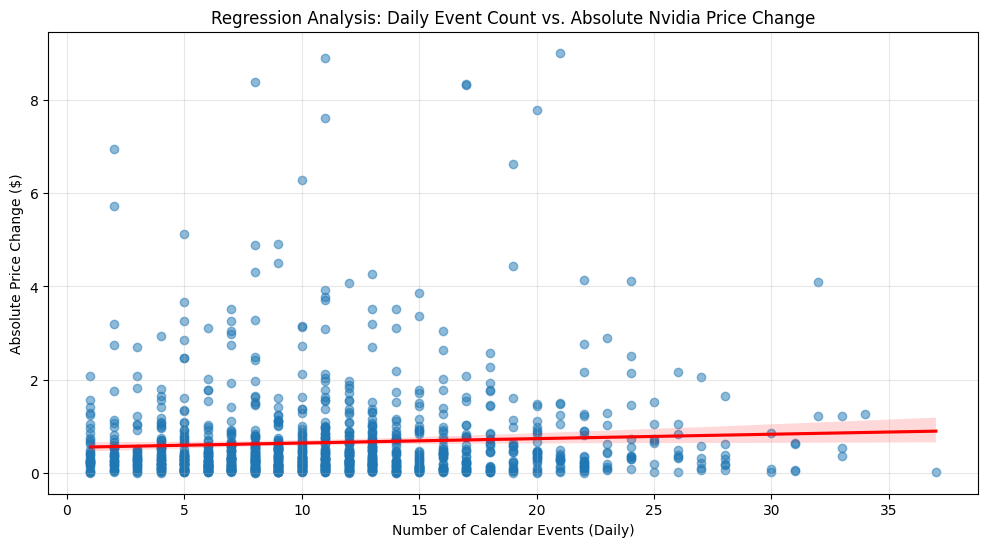

In [9]:
import seaborn as sns

# Visualize the relationship with a better plot
if 'model' in locals() and model is not None:
    plt.figure(figsize=(12, 6))

    # Use seaborn regplot for a scatter plot with a regression line and confidence interval
    sns.regplot(x='event_count', y='price_change', data=merged_df,
                scatter_kws={'alpha':0.5}, line_kws={'color':'red'})

    plt.title('Regression Analysis: Daily Event Count vs. Absolute Nvidia Price Change')
    plt.xlabel('Number of Calendar Events (Daily)')
    plt.ylabel('Absolute Price Change ($)')
    plt.grid(True, alpha=0.3)
    plt.show()
else:
    print("Model was not successfully created, skipping visualization.")